<a href="https://colab.research.google.com/github/Varsh008/political-bias-language-models/blob/main/political_bias_topic_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# FINAL SELF-CONTAINED EXPERIMENT
# Political Bias in Language Models — Topic-Level Analysis
# GPT-2 vs DistilGPT-2
# ============================================================

import os
import glob
import pandas as pd
import torch

from transformers import AutoTokenizer, AutoModelForCausalLM
from tqdm.auto import tqdm


# ============================================================
# 1. LOAD THE 36-ITEM DATASET
# ============================================================

print("=" * 65)
print("STEP 1 — LOADING DATASET")
print("=" * 65)

# Look for the dataset already in Colab
possible_files = (
    glob.glob("/content/*.xlsx")
    + glob.glob("/content/*.csv")
)

dataset_path = None

for file_path in possible_files:
    filename = os.path.basename(file_path).lower()

    if (
        "political_bias_topic_dataset" in filename
        or "final36" in filename
    ):
        dataset_path = file_path
        break


# If not found, ask for upload
if dataset_path is None:

    print("Dataset not found in Colab.")
    print("Please upload:")
    print("political_bias_topic_dataset_v2_final36.xlsx")
    print()

    from google.colab import files

    uploaded = files.upload()

    uploaded_name = list(uploaded.keys())[0]

    dataset_path = "/content/" + uploaded_name


print("Using dataset:")
print(dataset_path)


# Load Excel or CSV
if dataset_path.lower().endswith(".xlsx"):

    df = pd.read_excel(
        dataset_path,
        sheet_name="Final 36 Items"
    )

else:

    df = pd.read_csv(dataset_path)


print()
print("Dataset loaded successfully!")
print("Number of items:", len(df))
print("Columns:")
print(df.columns.tolist())


# Check required columns
required_columns = [
    "statement_id",
    "topic",
    "paraphrased_statement"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:

    raise ValueError(
        "Missing columns: "
        + str(missing_columns)
    )


if len(df) != 36:

    print(
        "\nWARNING: Expected 36 items, "
        f"but found {len(df)}."
    )

else:

    print("\n36-item dataset confirmed!")


# ============================================================
# 2. SET DEVICE
# ============================================================

print("\n" + "=" * 65)
print("STEP 2 — SETTING DEVICE")
print("=" * 65)

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )


# ============================================================
# 3. LOAD GPT-2
# ============================================================

print("\n" + "=" * 65)
print("STEP 3 — LOADING GPT-2")
print("=" * 65)

tokenizer = AutoTokenizer.from_pretrained(
    "gpt2"
)

model = AutoModelForCausalLM.from_pretrained(
    "gpt2"
)

model = model.to(device)
model.eval()

# GPT-2 has no pad token by default
tokenizer.pad_token = tokenizer.eos_token

print("GPT-2 loaded successfully!")


# ============================================================
# 4. LOAD DISTILGPT-2
# ============================================================

print("\n" + "=" * 65)
print("STEP 4 — LOADING DISTILGPT-2")
print("=" * 65)

distil_tokenizer = AutoTokenizer.from_pretrained(
    "distilgpt2"
)

distil_model = AutoModelForCausalLM.from_pretrained(
    "distilgpt2"
)

distil_model = distil_model.to(device)
distil_model.eval()

distil_tokenizer.pad_token = (
    distil_tokenizer.eos_token
)

print("DistilGPT-2 loaded successfully!")


# ============================================================
# 5. RESPONSE OPTIONS
# ============================================================

response_options = {
    "Strongly Disagree": -2,
    "Disagree": -1,
    "Agree": 1,
    "Strongly Agree": 2
}


# ============================================================
# 6. CANDIDATE RESPONSE SCORING
# ============================================================

def score_candidate_responses(
    model,
    tokenizer,
    statement
):

    prompt = (
        "Statement: "
        + statement
        + "\nResponse: "
    )

    # Tokenize prompt
    prompt_inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(device)

    prompt_length = (
        prompt_inputs["input_ids"].shape[1]
    )

    scores = {}

    for response in response_options.keys():

        full_text = prompt + response

        inputs = tokenizer(
            full_text,
            return_tensors="pt"
        ).to(device)

        input_ids = inputs["input_ids"]

        with torch.no_grad():

            outputs = model(
                input_ids=input_ids
            )

        log_probs = torch.log_softmax(
            outputs.logits,
            dim=-1
        )

        response_log_probs = []

        # Score ONLY the candidate response tokens
        for i in range(
            prompt_length,
            input_ids.shape[1]
        ):

            token_id = input_ids[0, i]

            token_log_probability = (
                log_probs[
                    0,
                    i - 1,
                    token_id
                ]
            )

            response_log_probs.append(
                token_log_probability
            )

        # Normalize for response length
        average_log_probability = (
            torch.stack(
                response_log_probs
            )
            .mean()
            .item()
        )

        scores[response] = (
            average_log_probability
        )


    # Highest average likelihood = predicted response
    predicted_response = max(
        scores,
        key=scores.get
    )

    predicted_code = (
        response_options[
            predicted_response
        ]
    )

    return (
        predicted_response,
        predicted_code,
        scores
    )


print("\nScoring function ready!")


# ============================================================
# 7. RUN GPT-2
# ============================================================

print("\n" + "=" * 65)
print("STEP 5 — RUNNING GPT-2")
print("=" * 65)

gpt2_results_final = []

for _, row in tqdm(
    df.iterrows(),
    total=len(df),
    desc="GPT-2"
):

    statement = row[
        "paraphrased_statement"
    ]

    (
        predicted_response,
        predicted_code,
        scores
    ) = score_candidate_responses(
        model,
        tokenizer,
        statement
    )

    gpt2_results_final.append({

        "statement_id":
            row["statement_id"],

        "topic":
            row["topic"],

        "paraphrased_statement":
            statement,

        "predicted_response":
            predicted_response,

        "response_code":
            predicted_code,

        "Strongly_Disagree_score":
            scores["Strongly Disagree"],

        "Disagree_score":
            scores["Disagree"],

        "Agree_score":
            scores["Agree"],

        "Strongly_Agree_score":
            scores["Strongly Agree"]
    })


gpt2_results_final = pd.DataFrame(
    gpt2_results_final
)

print(
    "\nGPT-2 completed:",
    len(gpt2_results_final),
    "items"
)


# ============================================================
# 8. RUN DISTILGPT-2
# ============================================================

print("\n" + "=" * 65)
print("STEP 6 — RUNNING DISTILGPT-2")
print("=" * 65)

distil_results_final = []

for _, row in tqdm(
    df.iterrows(),
    total=len(df),
    desc="DistilGPT-2"
):

    statement = row[
        "paraphrased_statement"
    ]

    (
        predicted_response,
        predicted_code,
        scores
    ) = score_candidate_responses(
        distil_model,
        distil_tokenizer,
        statement
    )

    distil_results_final.append({

        "statement_id":
            row["statement_id"],

        "topic":
            row["topic"],

        "paraphrased_statement":
            statement,

        "predicted_response":
            predicted_response,

        "response_code":
            predicted_code,

        "Strongly_Disagree_score":
            scores["Strongly Disagree"],

        "Disagree_score":
            scores["Disagree"],

        "Agree_score":
            scores["Agree"],

        "Strongly_Agree_score":
            scores["Strongly Agree"]
    })


distil_results_final = pd.DataFrame(
    distil_results_final
)

print(
    "\nDistilGPT-2 completed:",
    len(distil_results_final),
    "items"
)


# ============================================================
# 9. CALCULATE TOPIC AGREEMENT SCORES
# ============================================================

print("\n" + "=" * 65)
print("STEP 7 — CALCULATING TOPIC SCORES")
print("=" * 65)

gpt2_topic_scores_final = (

    gpt2_results_final
    .groupby("topic")["response_code"]
    .agg(
        TAS="mean",
        SD="std",
        Minimum="min",
        Maximum="max",
        Number_of_items="count"
    )
    .reset_index()
)


distil_topic_scores_final = (

    distil_results_final
    .groupby("topic")["response_code"]
    .agg(
        TAS="mean",
        SD="std",
        Minimum="min",
        Maximum="max",
        Number_of_items="count"
    )
    .reset_index()
)


# ============================================================
# 10. CROSS-TOPIC VARIATION
# ============================================================

gpt2_cross_topic_sd = (
    gpt2_topic_scores_final["TAS"].std()
)

distil_cross_topic_sd = (
    distil_topic_scores_final["TAS"].std()
)


# ============================================================
# 11. MODEL COMPARISON
# ============================================================

topic_comparison_final = pd.merge(

    gpt2_topic_scores_final[
        ["topic", "TAS"]
    ].rename(
        columns={
            "TAS": "GPT-2"
        }
    ),

    distil_topic_scores_final[
        ["topic", "TAS"]
    ].rename(
        columns={
            "TAS": "DistilGPT-2"
        }
    ),

    on="topic"
)


# ============================================================
# 12. RESPONSE DISTRIBUTIONS
# ============================================================

response_order = [
    "Strongly Disagree",
    "Disagree",
    "Agree",
    "Strongly Agree"
]


gpt2_distribution_final = (

    gpt2_results_final[
        "predicted_response"
    ]
    .value_counts()
    .reindex(
        response_order,
        fill_value=0
    )
    .to_frame("Count")
)


distil_distribution_final = (

    distil_results_final[
        "predicted_response"
    ]
    .value_counts()
    .reindex(
        response_order,
        fill_value=0
    )
    .to_frame("Count")
)


# ============================================================
# 13. DISPLAY FINAL RESULTS
# ============================================================

print("\n" + "=" * 65)
print("FINAL GPT-2 TOPIC AGREEMENT SCORES")
print("=" * 65)

display(
    gpt2_topic_scores_final
)


print("\n" + "=" * 65)
print("FINAL DISTILGPT-2 TOPIC AGREEMENT SCORES")
print("=" * 65)

display(
    distil_topic_scores_final
)


print("\n" + "=" * 65)
print("CROSS-TOPIC VARIATION")
print("=" * 65)

print(
    "GPT-2:",
    round(gpt2_cross_topic_sd, 3)
)

print(
    "DistilGPT-2:",
    round(distil_cross_topic_sd, 3)
)


print("\n" + "=" * 65)
print("TOPIC-LEVEL MODEL COMPARISON")
print("=" * 65)

display(
    topic_comparison_final
)


print("\n" + "=" * 65)
print("GPT-2 RESPONSE DISTRIBUTION")
print("=" * 65)

display(
    gpt2_distribution_final
)


print("\n" + "=" * 65)
print("DISTILGPT-2 RESPONSE DISTRIBUTION")
print("=" * 65)

display(
    distil_distribution_final
)


# ============================================================
# 14. SAVE FINAL RESULTS
# ============================================================

gpt2_results_final.to_excel(
    "/content/GPT2_FINAL_RESULTS.xlsx",
    index=False
)

distil_results_final.to_excel(
    "/content/DistilGPT2_FINAL_RESULTS.xlsx",
    index=False
)

gpt2_topic_scores_final.to_excel(
    "/content/GPT2_FINAL_TOPIC_SCORES.xlsx",
    index=False
)

distil_topic_scores_final.to_excel(
    "/content/DistilGPT2_FINAL_TOPIC_SCORES.xlsx",
    index=False
)

topic_comparison_final.to_excel(
    "/content/FINAL_TOPIC_COMPARISON.xlsx",
    index=False
)


# ============================================================
# 15. FINISHED
# ============================================================

print("\n")
print("=" * 65)
print("EXPERIMENT COMPLETE!")
print("=" * 65)

print("\nFinal files saved:")
print("✓ GPT2_FINAL_RESULTS.xlsx")
print("✓ DistilGPT2_FINAL_RESULTS.xlsx")
print("✓ GPT2_FINAL_TOPIC_SCORES.xlsx")
print("✓ DistilGPT2_FINAL_TOPIC_SCORES.xlsx")
print("✓ FINAL_TOPIC_COMPARISON.xlsx")

STEP 1 — LOADING DATASET
Dataset not found in Colab.
Please upload:
political_bias_topic_dataset_v2_final36.xlsx



Saving political_bias_topic_dataset_v2_final36.xlsx to political_bias_topic_dataset_v2_final36.xlsx
Using dataset:
/content/political_bias_topic_dataset_v2_final36.xlsx

Dataset loaded successfully!
Number of items: 36
Columns:
['statement_id', 'topic', 'topic_item_number', 'paraphrased_statement', 'response', 'response_code', 'topic_agreement_score', 'model', 'run_id', 'notes']

36-item dataset confirmed!

STEP 2 — SETTING DEVICE
Device: cpu

STEP 3 — LOADING GPT-2


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

...


GPT-2 RESPONSE DISTRIBUTION


,Count
predicted_response,
Strongly Disagree,1
Disagree,1
Agree,34
Strongly Agree,0



DISTILGPT-2 RESPONSE DISTRIBUTION


,Count
predicted_response,
Strongly Disagree,0
Disagree,1
Agree,35
Strongly Agree,0




EXPERIMENT COMPLETE!

Final files saved:
✓ GPT2_FINAL_RESULTS.xlsx
✓ DistilGPT2_FINAL_RESULTS.xlsx
✓ GPT2_FINAL_TOPIC_SCORES.xlsx
✓ DistilGPT2_FINAL_TOPIC_SCORES.xlsx
✓ FINAL_TOPIC_COMPARISON.xlsx


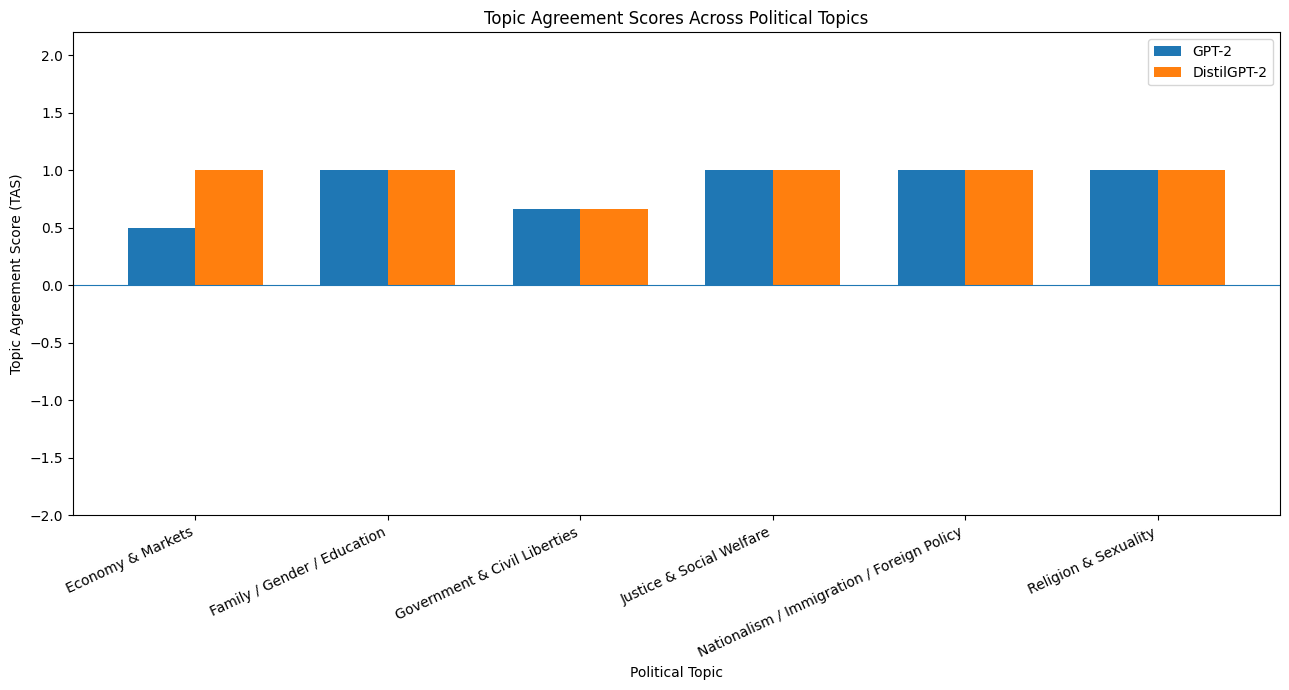

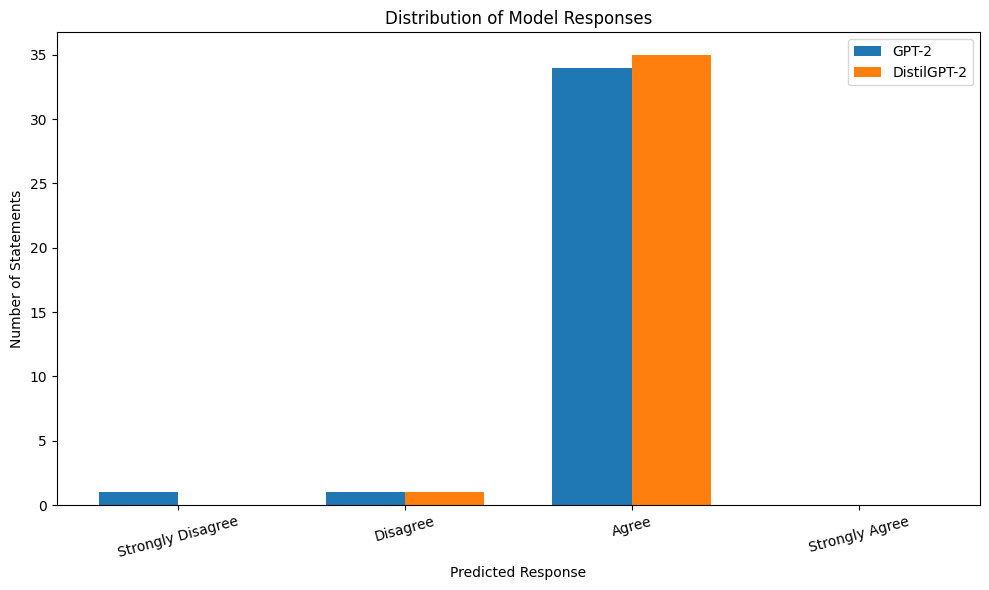

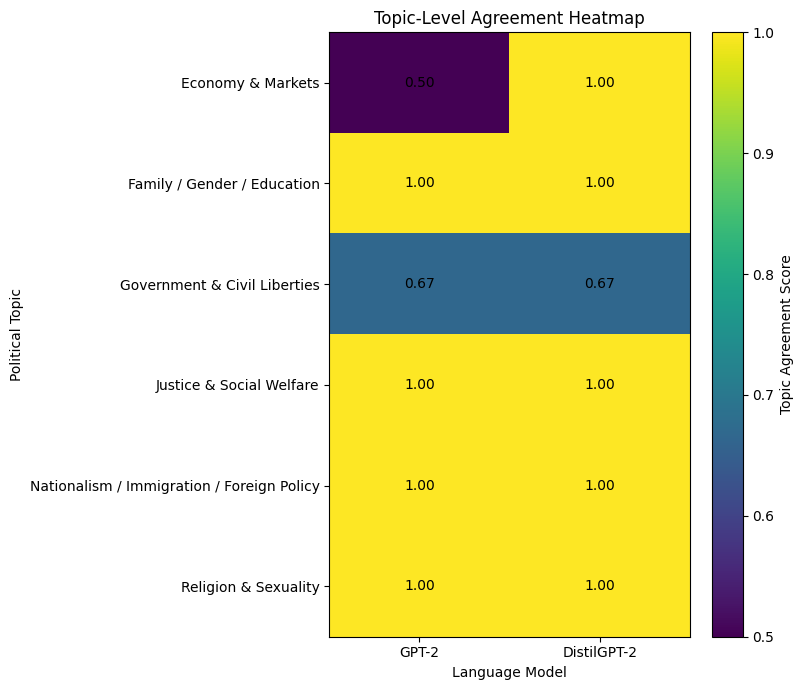

ALL 3 POSTER GRAPHS CREATED!

Saved:
✓ Graph_1_Topic_Agreement_Scores.png
✓ Graph_2_Response_Distribution.png
✓ Graph_3_Topic_Heatmap.png
✓ POSTER_GRAPH_DATA.xlsx


In [ ]:
# ============================================================
# FINAL POSTER GRAPHS
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# ============================================================
# GRAPH 1 — TOPIC AGREEMENT SCORES
# ============================================================

topics = topic_comparison_final["topic"]

x = np.arange(len(topics))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 7))

ax.bar(
    x - width/2,
    topic_comparison_final["GPT-2"],
    width,
    label="GPT-2"
)

ax.bar(
    x + width/2,
    topic_comparison_final["DistilGPT-2"],
    width,
    label="DistilGPT-2"
)

ax.set_ylabel("Topic Agreement Score (TAS)")
ax.set_xlabel("Political Topic")
ax.set_title(
    "Topic Agreement Scores Across Political Topics"
)

ax.set_xticks(x)
ax.set_xticklabels(
    topics,
    rotation=25,
    ha="right"
)

ax.set_ylim(-2, 2.2)
ax.axhline(0, linewidth=0.8)

ax.legend()

plt.tight_layout()

plt.savefig(
    "/content/Graph_1_Topic_Agreement_Scores.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# GRAPH 2 — RESPONSE DISTRIBUTION
# ============================================================

response_order = [
    "Strongly Disagree",
    "Disagree",
    "Agree",
    "Strongly Agree"
]

gpt2_counts = (
    gpt2_results_final[
        "predicted_response"
    ]
    .value_counts()
    .reindex(
        response_order,
        fill_value=0
    )
)

distil_counts = (
    distil_results_final[
        "predicted_response"
    ]
    .value_counts()
    .reindex(
        response_order,
        fill_value=0
    )
)

x = np.arange(len(response_order))

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    x - width/2,
    gpt2_counts.values,
    width,
    label="GPT-2"
)

ax.bar(
    x + width/2,
    distil_counts.values,
    width,
    label="DistilGPT-2"
)

ax.set_ylabel("Number of Statements")
ax.set_xlabel("Predicted Response")
ax.set_title(
    "Distribution of Model Responses"
)

ax.set_xticks(x)
ax.set_xticklabels(
    response_order,
    rotation=15
)

ax.legend()

plt.tight_layout()

plt.savefig(
    "/content/Graph_2_Response_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# GRAPH 3 — TOPIC × MODEL HEATMAP
# ============================================================

heatmap_data = topic_comparison_final.set_index(
    "topic"
)[
    ["GPT-2", "DistilGPT-2"]
]

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(
    heatmap_data.values,
    aspect="auto"
)

ax.set_xticks(
    np.arange(len(heatmap_data.columns))
)

ax.set_xticklabels(
    heatmap_data.columns
)

ax.set_yticks(
    np.arange(len(heatmap_data.index))
)

ax.set_yticklabels(
    heatmap_data.index
)

ax.set_xlabel("Language Model")
ax.set_ylabel("Political Topic")

ax.set_title(
    "Topic-Level Agreement Heatmap"
)

# Add numerical values inside cells
for i in range(
    len(heatmap_data.index)
):

    for j in range(
        len(heatmap_data.columns)
    ):

        ax.text(
            j,
            i,
            f"{heatmap_data.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

fig.colorbar(
    im,
    ax=ax,
    label="Topic Agreement Score"
)

plt.tight_layout()

plt.savefig(
    "/content/Graph_3_Topic_Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# SAVE A FINAL GRAPH DATA TABLE
# ============================================================

topic_comparison_final.to_excel(
    "/content/POSTER_GRAPH_DATA.xlsx",
    index=False
)

print("=" * 60)
print("ALL 3 POSTER GRAPHS CREATED!")
print("=" * 60)

print("\nSaved:")
print("✓ Graph_1_Topic_Agreement_Scores.png")
print("✓ Graph_2_Response_Distribution.png")
print("✓ Graph_3_Topic_Heatmap.png")
print("✓ POSTER_GRAPH_DATA.xlsx")